In [1]:
import sys
!{sys.executable} -m pip install seaborn

In [2]:
import sys
print(sys.executable)


c:\Users\Junha\miniconda3\envs\nba-research\python.exe


检查合并场上和场下数据后的csv 是否有逻辑问题

In [4]:
# EDA_6_VALIDATION_full_csv_level1.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/training_level1_full.csv")

print("Shape:", df.shape)
df.info()
df.describe()

pd.DataFrame({
    "n_unique": df.nunique().sort_values(ascending=False)
}).head(30)


Shape: (2082, 132)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2082 entries, 0 to 2081
Columns: 132 entries, player_id to injury_any
dtypes: bool(3), float64(110), int64(10), object(9)
memory usage: 2.1+ MB


,n_unique
TS%_calc,2000
PTS_per_min,1839
log1p_PTS_per_min,1829
FGA_per_min,1797
REB_per_min,1715
log1p_REB_per_min,1713
3PA_per_min,1653
PTS_per_gp,1648
DREB_per_min,1615
FGM_per_min,1601


In [5]:
df.isna().mean().sort_values(ascending=False).head(30)


overall_pick             0.159942
draft_is_second_round    0.159942
draft_year               0.159942
years_since_draft        0.159942
draft_is_lottery         0.159942
round                    0.159942
round_pick               0.159942
draft_is_first_round     0.159942
log_salary               0.000000
salary_usd               0.000000
season                   0.000000
player_id                0.000000
salary_cap               0.000000
salary_cap_ratio         0.000000
log_salary_cap_ratio     0.000000
salary_cap_equiv         0.000000
Age                      0.000000
GP                       0.000000
W                        0.000000
L                        0.000000
FTM                      0.000000
FTA                      0.000000
FT%                      0.000000
OREB                     0.000000
DREB                     0.000000
REB                      0.000000
AST                      0.000000
TOV                      0.000000
Min                      0.000000
PTS           

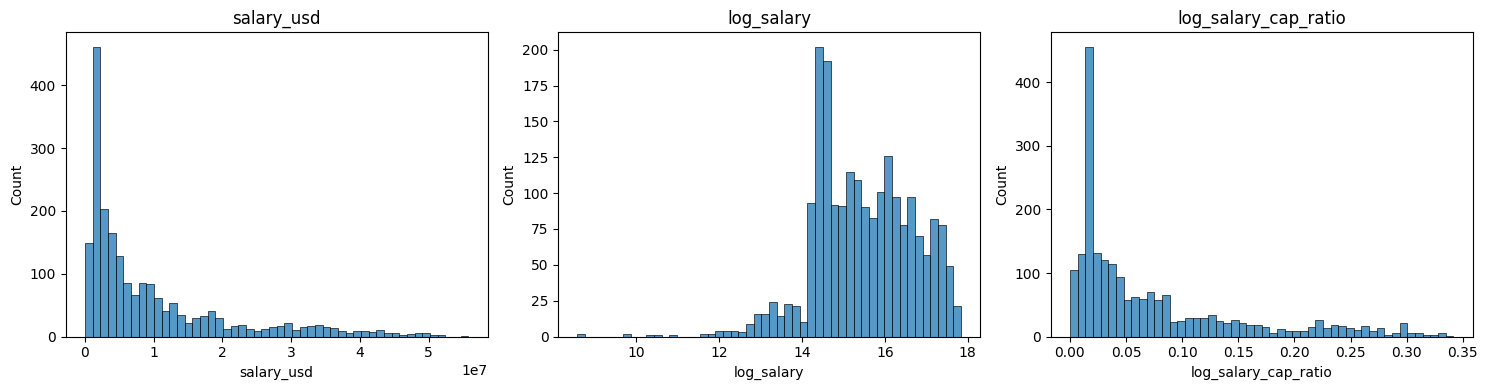

In [7]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

sns.histplot(df["salary_usd"], bins=50, ax=ax[0])
ax[0].set_title("salary_usd")

sns.histplot(df["log_salary"], bins=50, ax=ax[1])
ax[1].set_title("log_salary")

sns.histplot(df["log_salary_cap_ratio"], bins=50, ax=ax[2])
ax[2].set_title("log_salary_cap_ratio")

plt.tight_layout()


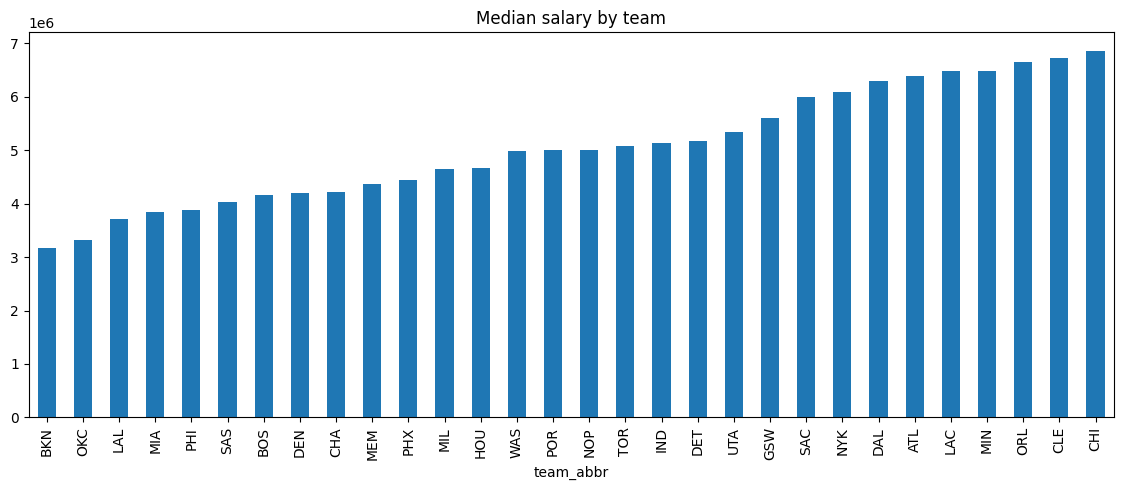

In [8]:
df.groupby("team_abbr")["salary_usd"].median().sort_values().plot(kind='bar', figsize=(14,5))
plt.title("Median salary by team")
plt.show()

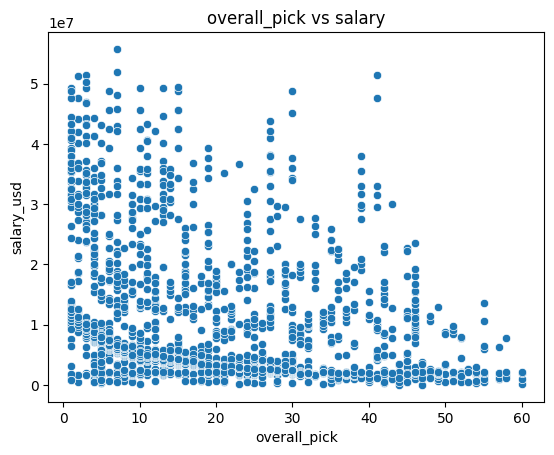

In [9]:
df.groupby("draft_is_lottery")["salary_usd"].median()
df.groupby("draft_is_first_round")["salary_usd"].median()
df.groupby("draft_is_second_round")["salary_usd"].median()

sns.scatterplot(df, x="overall_pick", y="salary_usd")
plt.title("overall_pick vs salary")
plt.show()


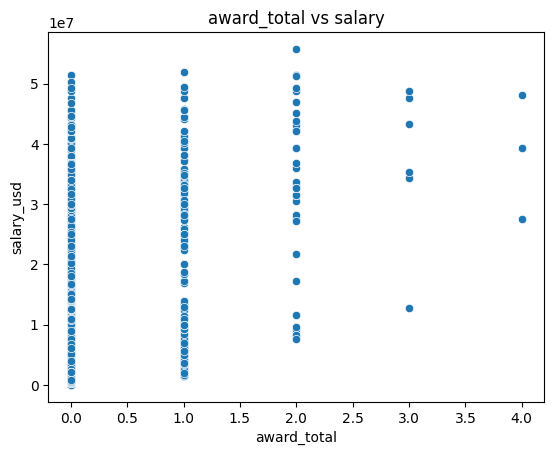

award_total
0.0     4500000.0
1.0    13986432.0
2.0    33047804.0
3.0    39282134.0
4.0    39344970.0
Name: salary_usd, dtype: float64

In [10]:
sns.scatterplot(df, x="award_total", y="salary_usd")
plt.title("award_total vs salary")
plt.show()

df.groupby("award_total")["salary_usd"].median().tail(10)


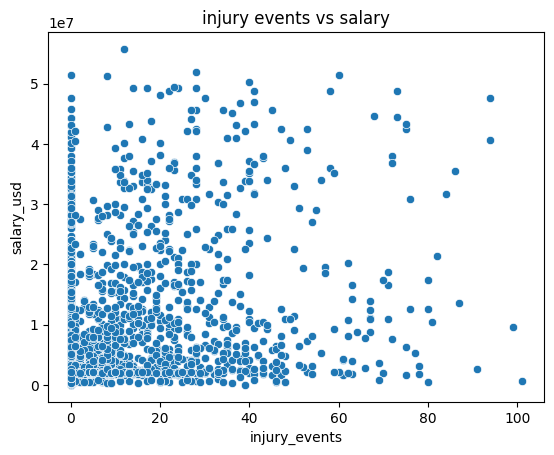

In [11]:
sns.scatterplot(df, x="injury_events", y="salary_usd")
plt.title("injury events vs salary")
plt.show()


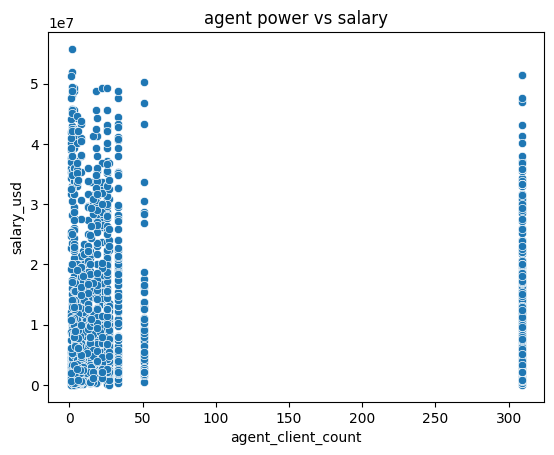

agent_is_top
False    5291000.0
True     4000000.0
Name: salary_usd, dtype: float64

In [12]:
sns.scatterplot(df, x="agent_client_count", y="salary_usd")
plt.title("agent power vs salary")
plt.show()

df.groupby("agent_is_top")["salary_usd"].median()

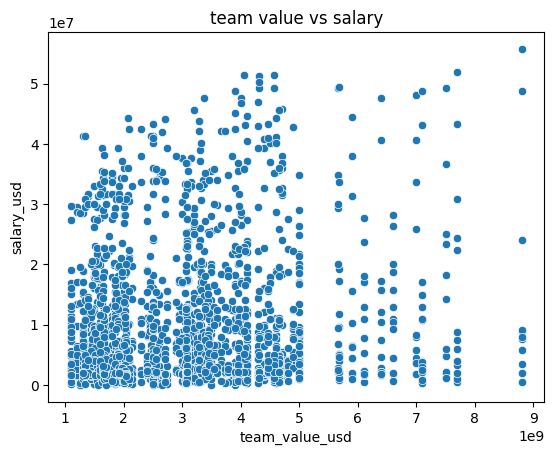

team_big_market_flag
False    4810200.0
True     5837760.0
Name: salary_usd, dtype: float64

In [14]:
sns.scatterplot(df, x="team_value_usd", y="salary_usd")
plt.title("team value vs salary")
plt.show()

df.groupby("team_big_market_flag")["salary_usd"].median()

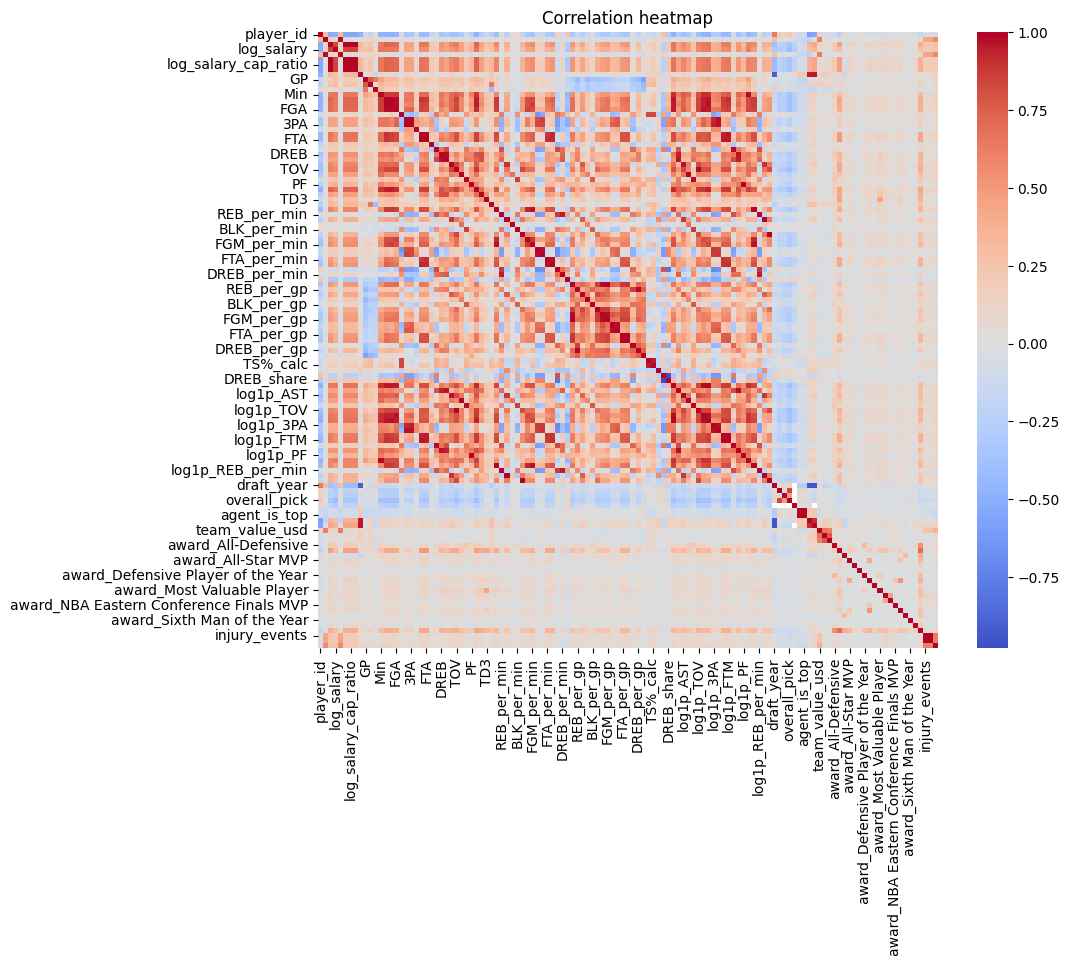

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()


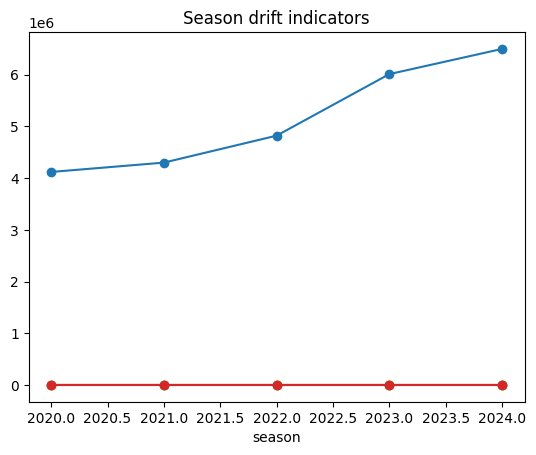

In [16]:
df.groupby("season")["salary_usd"].median().plot(marker="o")
df.groupby("season")["FP"].mean().plot(marker="o")
df.groupby("season")["injury_events"].mean().plot(marker="o")
df.groupby("season")["award_total"].mean().plot(marker="o")
plt.title("Season drift indicators")
plt.show()


In [13]:
summary = {
    "missing_over_50%": missing[missing > 0.5],
    "duplicates": dupes,
    "negative_salaries": (df["salary_usd"] < 0).sum(),
    "invalid_age": (df["age_now"] < 18).sum(),
    "invalid_salary": df["salary_usd"].isna().sum(),
}

print("===== DATA VALIDATION SUMMARY =====")
summary


===== DATA VALIDATION SUMMARY =====


{'missing_over_50%': Series([], dtype: float64),
 'duplicates': np.int64(0),
 'negative_salaries': np.int64(0),
 'invalid_age': np.int64(0),
 'invalid_salary': np.int64(0)}